In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")


In [2]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [3]:
def recursive_forecast(model, data, n_steps=12, n_lags=12):
    """
    Generate recursive multi-step forecasts for monthly data using a trained model.
    
    Parameters:
    - model: trained ML model (e.g., XGBoost)
    - data: pd.DataFrame with a 'y' column and datetime index
    - n_steps: number of months to forecast
    - n_lags: number of lag features to use
    
    Returns:
    - forecast: pd.Series of predicted values with datetime index
    """
    last_data = data.copy()
    forecast = []
    
    for i in range(n_steps):
        # Compute lag features
        lags = [last_data['y'].iloc[-lag] for lag in range(1, n_lags + 1)]
        
        # Rolling statistics
        rolling_3 = np.mean([last_data['y'].iloc[-j] for j in range(1, min(4, len(last_data)+1))])
        rolling_6 = np.mean([last_data['y'].iloc[-j] for j in range(1, min(7, len(last_data)+1))])
        
        # Month features
        next_month = last_data.index[-1] + pd.DateOffset(months=1)
        month_sin = np.sin(2 * np.pi * next_month.month / 12)
        month_cos = np.cos(2 * np.pi * next_month.month / 12)
        
        # Combine features
        X_next = np.array(lags + [rolling_3, rolling_6, next_month.month, month_sin, month_cos]).reshape(1, -1)
        
        # Predict next value
        y_next = model.predict(X_next)[0]
        forecast.append(y_next)
        
        # Append prediction for next iteration
        last_data = pd.concat([last_data, pd.DataFrame({'y': [y_next]}, index=[next_month])])
    
    forecast_index = pd.date_range(start=last_data.index[-n_steps], periods=n_steps, freq='MS')
    return pd.Series(forecast, index=forecast_index)

    

In [4]:
loaded_data = load_data()
data = pd.DataFrame({
    'date': loaded_data['date'],
    'y': loaded_data['tmed']
})

data.set_index('date', inplace=True)

C:\Users\Afonso Viveiros\OneDrive\Documentos\TSF-PROJ\utils.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
C:\Users\Afonso Viveiros\OneDrive\Documentos\TSF-PROJ\utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
C:\Users\Afonso Viveiros\OneDrive\Documentos\TSF-PROJ\utils.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [5]:
data.head()

,y
date,
1995-01-01,9.77
1995-02-01,10.87
1995-03-01,12.54
1995-04-01,15.11
1995-05-01,17.84


In [6]:
# Add lag features (1 to 12 months)
for lag in range(1, 13):
    data[f'lag_{lag}'] = data['y'].shift(lag)

# Add rolling mean features
data['rolling_3'] = data['y'].shift(1).rolling(3).mean()
data['rolling_6'] = data['y'].shift(1).rolling(6).mean()

# Add cyclical month features
data['month'] = data.index.month
data['month_sin'] = np.sin(2 * np.pi * data['month']/12)
data['month_cos'] = np.cos(2 * np.pi * data['month']/12)

# Drop rows with NaN from lag/rolling features
data.dropna(inplace=True)

In [7]:
data.head()

,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_3,rolling_6,month,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,
1996-01-01,10.46,11.18,14.21,18.57,18.62,23.51,22.63,20.25,17.84,15.11,12.54,10.87,9.77,14.653333,18.120000,1,0.500000,8.660254e-01
1996-02-01,8.71,10.46,11.18,14.21,18.57,18.62,23.51,22.63,20.25,17.84,15.11,12.54,10.87,11.950000,16.091667,2,0.866025,5.000000e-01
1996-03-01,11.98,8.71,10.46,11.18,14.21,18.57,18.62,23.51,22.63,20.25,17.84,15.11,12.54,10.116667,13.625000,3,1.000000,6.123234e-17
1996-04-01,14.61,11.98,8.71,10.46,11.18,14.21,18.57,18.62,23.51,22.63,20.25,17.84,15.11,10.383333,12.518333,4,0.866025,-5.000000e-01
1996-05-01,15.82,14.61,11.98,8.71,10.46,11.18,14.21,18.57,18.62,23.51,22.63,20.25,17.84,11.766667,11.858333,5,0.500000,-8.660254e-01


In [8]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = recursive_forecast(rf, train, n_steps=len(test))

print("Random Forest:")
evaluate(y_test, y_pred_rf)

Random Forest:
MAE: 1.0271619660582156
RMSE: 1.2611915810203267


In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)
y_pred_xgb = recursive_forecast(xgb, train, n_steps=len(test)) #xgb.predict(X_test)

print("\nXGBoost:")
evaluate(y_test, y_pred_xgb)


XGBoost:
MAE: 1.213942922394851
RMSE: 1.4092758605792597


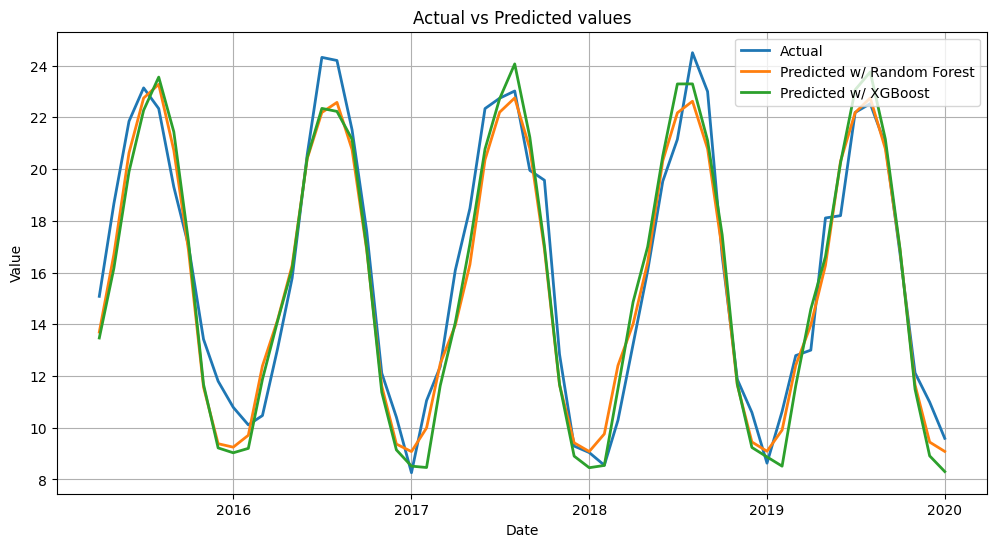

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, y_pred_rf, label="Predicted w/ Random Forest", linewidth=2)
plt.plot(y_test.index, y_pred_xgb, label="Predicted w/ XGBoost", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()